# Pipeline de Execução do Projeto

Neste notebook, será definida a pipeline de execução utilizada ao longo do projeto.  
A estrutura seguirá as seguintes etapas:

1. **Importação das bibliotecas**  
   Importação de todas as bibliotecas necessárias para o desenvolvimento do projeto.

2. **Download e preparação dos recursos**  
   Download dos dados, arquiteturas e de qualquer outro recurso necessário para a execução dos experimentos.

3. **Carregamento e pré-processamento dos dados**  
   Carregamento dos datasets, realização do pré-processamento, criação dos *DataLoaders* e visualização dos dados.  
   Nesta etapa, será possível escolher qual conjunto de dados utilizar, como **MNIST** ou **CIFAR-10**.

4. **Definição das arquiteturas**  
   Seleção e carregamento das arquiteturas baseadas em **Contrastive Loss (Duplet)**, **Triplet Loss** e **SimCLR**.

5. **Pipeline de treinamento**  
   Definição e execução do processo de treinamento dos modelos.

6. **Pipeline de teste**  
   Avaliação dos modelos treinados sobre os dados de teste.

7. **Avaliação e visualização das representações**  
   Análise das representações aprendidas por meio de técnicas de visualização, como **t-SNE** e **UMAP**.


## 1 - Importação das bibliotecas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

from sklearn.datasets import fetch_openml
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import umap

import pandas as pd
import numpy as np
import random
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm


from models import MLP, LeNet, AlexNet, TripletNetwork, SiameseNetwork
from datasets import TripletDataset, SiameseDataset
from loss import ContrastiveLoss

import os

In [2]:
torch.manual_seed(42)

#Definições e configurações:
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_dim = 128
LR = 1e-3
EPOCHS = 1

#escolha de dataset
dataset = "MNIST" #MNIST ou CIFAR10

In [3]:
DEVICE

device(type='cpu')


## 2 - Download e preparação dos recursos

In [4]:
#MNIST
datasets.MNIST(root="./data", train=True, download=True)
datasets.MNIST(root="./data", train=False, download=True)

#CIFAR10
datasets.CIFAR10(root="./data", train=True, download=True)
datasets.CIFAR10(root="./data", train=False, download=True)

print("MNIST and CIFAR10 Downloaded")

MNIST and CIFAR10 Downloaded



## 3 - Carregamento e pré-processamento dos dados

In [5]:
if dataset == "MNIST":
    train_dataset = datasets.MNIST(root="./data", train=True, transform=transforms.ToTensor())
    test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

if dataset == "CIFAR10":
    train_dataset = datasets.CIFAR10(root="./data", train=True, transform=transforms.ToTensor())
    test_dataset = datasets.CIFAR10(root="./data", train=False, transform=transforms.ToTensor())
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#Possíveis evoluções no futuro
# if dataset == "FashionMNIST":

# if dataset == "CIFAR100":

print(f"Dataset {dataset} Loaded")
print(f"Trainloader Size: {len(train_dataloader)}")
print(f"Testloader Size: {len(test_dataloader)}")



Dataset MNIST Loaded
Trainloader Size: 938
Testloader Size: 157


torch.Size([64, 1, 28, 28])


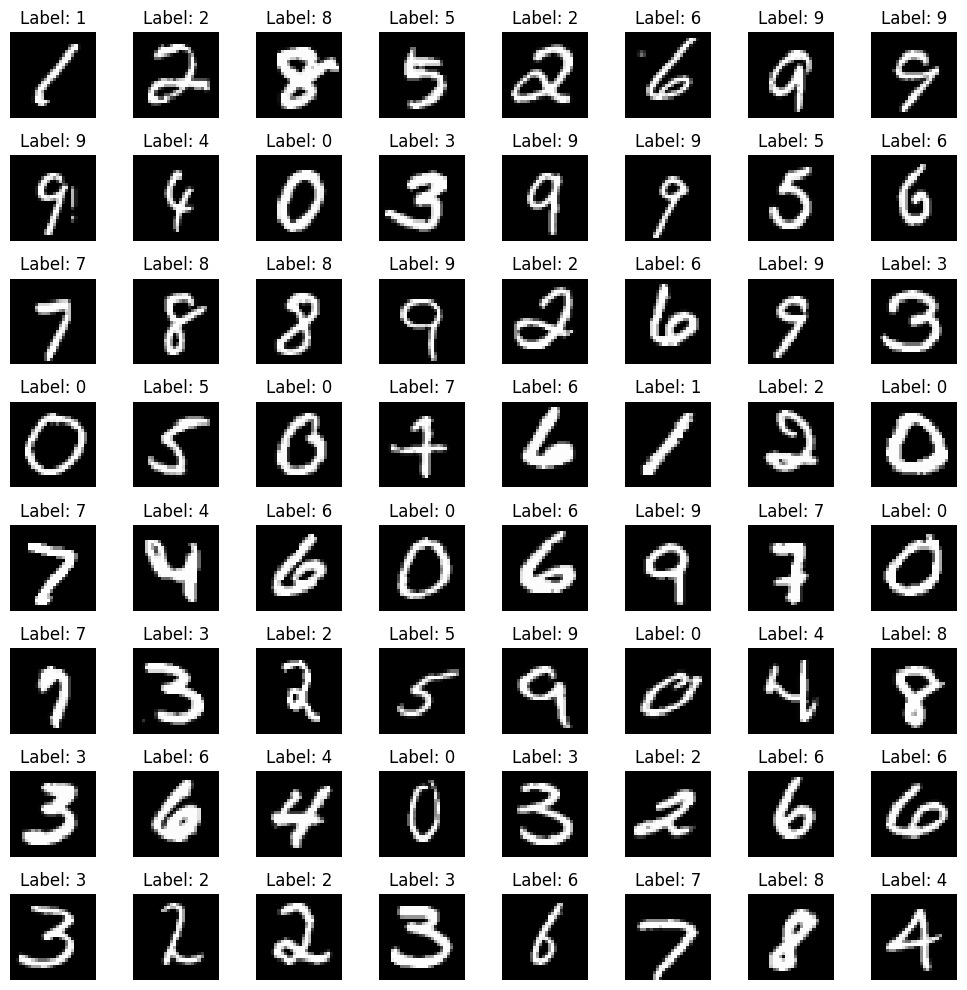

In [6]:
X, y = next(iter(train_dataloader))

print(X.shape)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
axes = axes.flatten()

for i in range(64):
    axes[i].imshow(X[i].permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Label: {y[i].item()}")

plt.tight_layout()
plt.show()

In [7]:
def plot_pair(img1, img2, label):
    # Converter tensor para valor
    label_value = int(label.item())

    # Definir título
    title = "Diferentes" if label_value == 1 else "Similares"

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    img1_disp = img1.permute(1, 2, 0).numpy()
    img2_disp = img2.permute(1, 2, 0).numpy()
    
    axes[0].imshow(img1_disp, cmap="gray")
    axes[0].axis("off")

    axes[1].imshow(img2_disp, cmap="gray")
    axes[1].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.show()


In [8]:
train_siamesedataset = SiameseDataset(train_dataset)
train_siamese_dataloader = DataLoader(train_siamesedataset, batch_size=BATCH_SIZE, shuffle=True)
test_siamesedataset = SiameseDataset(test_dataset)
test_siamese_dataloader = DataLoader(test_siamesedataset, batch_size=BATCH_SIZE, shuffle=False)

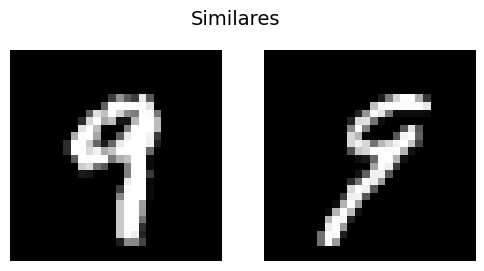

In [9]:
batch = next(iter(train_siamese_dataloader))
plot_pair(batch[0][0], batch[1][0], batch[2][0])


## 4 - Definição das arquiteturas

In [10]:
#Classifier = MLP(input_dim=len(train_dataset[0][0].squeeze().flatten()), output_dim = embedding_dim )
#Classifier = LeNet(input_dim = len(train_dataset[0][0]), output_dim = embedding_dim)
Classifier = AlexNet(input_dim = len(train_dataset[0][0]), output_dim = embedding_dim)

In [11]:
#Teste com um batch
Classifier.eval()
logits = Classifier(X)
logits[:10], logits.shape

(tensor([[ 0.0449, -0.0219, -0.0116,  ...,  0.0020, -0.0227, -0.0324],
         [ 0.0449, -0.0217, -0.0115,  ...,  0.0027, -0.0225, -0.0322],
         [ 0.0454, -0.0217, -0.0110,  ...,  0.0030, -0.0228, -0.0315],
         ...,
         [ 0.0449, -0.0218, -0.0115,  ...,  0.0025, -0.0226, -0.0322],
         [ 0.0450, -0.0218, -0.0116,  ...,  0.0023, -0.0226, -0.0322],
         [ 0.0449, -0.0219, -0.0117,  ...,  0.0021, -0.0227, -0.0324]],
        grad_fn=<SliceBackward0>),
 torch.Size([64, 128]))

In [12]:
#Definição do Modelo
model = SiameseNetwork(Classifier)


## 5 - Teste Inicial

In [13]:
#Criar uma pasta para o experimento

file = f"test/{model.__class__.__name__}/{Classifier.__class__.__name__}_{dataset}_{embedding_dim}_{LR}_{EPOCHS}/{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs("test", exist_ok=True)
os.makedirs(file, exist_ok=True)

In [14]:
def evaluate_embeddings(model, dataloader, title="Embedding Evaluation"):
    model.eval()
    
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader):
            # Tenta descobrir de forma inteligente o que o dataloader está retornando
            if len(batch) == 2 and batch[1].ndim == 1:
                # Dataloader Padrão (x, label_real)
                x, y = batch
            elif len(batch) == 3 and batch[2].ndim == 1 and batch[2].max() > 1:
                # SupCon Dataset (x1, x2, label_real)
                x, _, y = batch
            else:
                # Se for Siamese, Triplet ou SimCLR puro, apenas pegamos o primeiro item (x)
                # Isso não é o ideal para a curva de distribuição, por isso vou avisar abaixo
                print("AVISO: Para a melhor avaliação cruzada, passe o 'test_dataloader' padrão (com labels reais) na função!")
                x = batch[0]
                # Usa uma label fictícia apenas para o código não quebrar
                y = torch.zeros(x.size(0))
                
            x = x.to(DEVICE)
            z = F.normalize(model.embed(x), dim=1)
            embeddings.append(z.cpu())
            labels.append(y.cpu())
            
    embeddings = torch.cat(embeddings, dim=0) 
    labels = torch.cat(labels, dim=0) 
    
    if len(embeddings) > 2000:
        idx = torch.randperm(len(embeddings))[:2000]
        sub_emb = embeddings[idx]
        sub_labels = labels[idx]
    else:
        sub_emb = embeddings
        sub_labels = labels
    
    # Calcula a distância vetorial entre todo mundo (Matriz 2000 x 2000)
    dist_matrix = torch.cdist(sub_emb, sub_emb, p=2) 
    
    # Máscara para pegar distâncias de Classes Iguais (Positivos)
    same_class_mask = torch.eq(sub_labels.unsqueeze(1), sub_labels.unsqueeze(0))
    same_class_mask.fill_diagonal_(False) # Ignora a distância da imagem com ela mesma
    
    # Máscara para Classes Diferentes (Negativos)
    diff_class_mask = ~torch.eq(sub_labels.unsqueeze(1), sub_labels.unsqueeze(0))
    
    pos = dist_matrix[same_class_mask].numpy()
    neg = dist_matrix[diff_class_mask].numpy()

    # Plot das Curvas
    plt.figure()
    plt.hist(pos, bins=50, alpha=0.5, label="similar", density=True)
    plt.hist(neg, bins=50, alpha=0.5, label="different", density=True)

    # Threshold com Acurácia Balanceada (Sensibilidade e Especificidade)
    all_dist = np.concatenate([pos, neg])
    thresholds = np.linspace(all_dist.min(), all_dist.max(), 200)

    accs = []
    for t in thresholds: #find the accuracy of all thresholds
        tpr = np.sum(pos < t) / len(pos) if len(pos) > 0 else 0
        tnr = np.sum(neg > t) / len(neg) if len(neg) > 0 else 0
        acc = (tpr + tnr) / 2.0
        accs.append(acc)

    #find the best accuracy
    best_idx = np.argmax(accs)
    best_t = thresholds[best_idx]
    best_acc = accs[best_idx]

    plt.axvline(best_t, linestyle="--", label=f"thr={best_t:.2f}") #print the accuracy
    plt.legend()
    plt.title(title)
    plt.show()

    print(f"Separation: {(neg.mean() - pos.mean()):.4f}")
    print(f"Balanced Accuracy: {best_acc:.4f}")

    plt.savefig(f"{file}/{title}.png")

    return (neg.mean() - pos.mean()), best_acc


  0%|          | 0/157 [00:00<?, ?it/s]

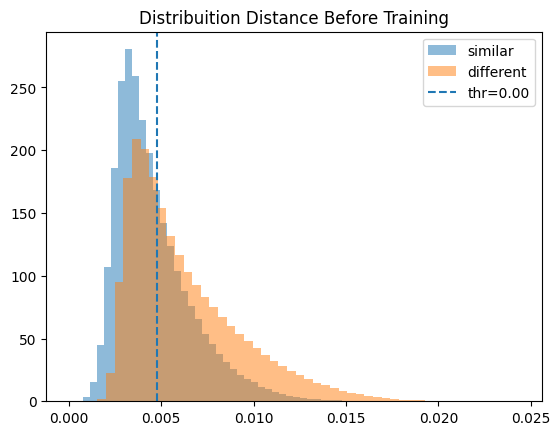

Separation: 0.0017
Balanced Accuracy: 0.6151


<Figure size 640x480 with 0 Axes>

In [15]:
sepration_pre_training, accuracy_pre_trainin = evaluate_embeddings(model, test_dataloader, title="Distribuition Distance Before Training")


## 6 - Pipeline de treinamento

In [16]:
def train(model, dataloader, optimizer, epochs, device):

    model.to(device)
    loss_history = []

    epoch_pbar = tqdm(range(epochs), desc="Training Progress")

    for epoch in epoch_pbar:
        model.train()
        batch_pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

        for batch in batch_pbar:
            batch = [b.to(device) for b in batch]

            optimizer.zero_grad()

            loss = model.training_step(batch)

            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
            batch_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    return loss_history


In [17]:
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

loss = train(model, train_siamese_dataloader, optimizer, EPOCHS, DEVICE)

Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/938 [00:00<?, ?it/s]


## 6 - Pipeline de teste

In [18]:
# Loss Curve
loss_df = pd.DataFrame({"loss": loss})
loss_df.to_csv(os.path.join(file, "loss_curve.csv"), index=False)

In [19]:
def plot_loss_curve(loss_history):

    plt.figure(figsize=(8,5))

    plt.plot(loss_history)

    plt.xlabel("Training Step")
    plt.ylabel("Contrastive Loss")
    plt.title("Training Loss Curve")

    plt.grid(True)
    plt.savefig(f"{file}/loss_curve.png")
    plt.show()

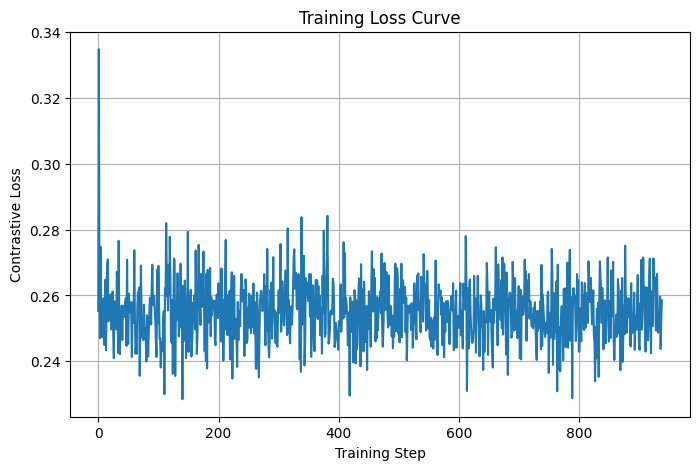

In [20]:
plot_loss_curve(loss)

  0%|          | 0/157 [00:00<?, ?it/s]

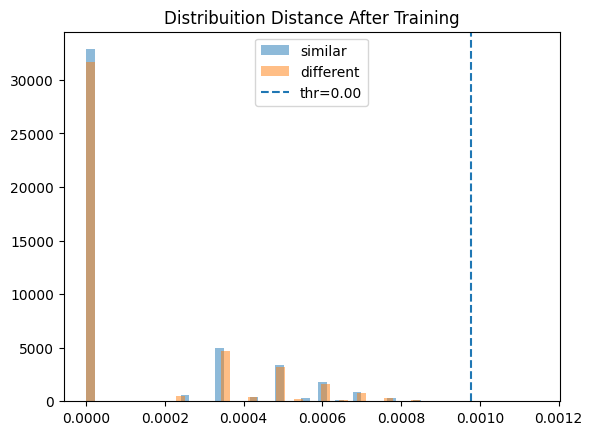

Separation: -0.0000
Balanced Accuracy: 0.5000


<Figure size 640x480 with 0 Axes>

In [21]:
sepration_pos_training, accuracy_pos_training = evaluate_embeddings(model, test_dataloader, title="Distribuition Distance After Training")


## 7 - Avaliação e visualização das representações

In [22]:
def get_embeddings(dataloader, model, device):
    model.eval()
    model.to(device)

    with torch.no_grad():
        embeddings = []
        labels = []

        for data, label in tqdm(dataloader):
            data = data.to(device)
            embedding = model.embed(data)
            embeddings.append(embedding.cpu().numpy())
            labels.append(label.cpu().numpy())

        return np.concatenate(embeddings, axis=0), np.concatenate(labels, axis=0)


In [23]:
def get_random_samples(data, labels, samples_per_class=200):
    """
    Amostra uma quantidade igual de exemplos para cada classe.
    Se a classe tiver menos amostras do que o solicitado, pega todas as disponíveis.
    """
    data = np.array(data)
    labels = np.array(labels)
    
    sampled_data = []
    sampled_labels = []
    
    # Unique classes
    unique_classes = np.unique(labels)
    
    for cls in unique_classes:
        cls_idx = np.where(labels == cls)[0]
        
        n_samples = min(samples_per_class, len(cls_idx))
        
        chosen_idx = np.random.choice(cls_idx, n_samples, replace=False)
        
        sampled_data.append(data[chosen_idx])
        sampled_labels.append(labels[chosen_idx])

    final_data = np.concatenate(sampled_data, axis=0)
    final_labels = np.concatenate(sampled_labels, axis=0)
    
    return final_data, final_labels


In [24]:
def plot_tsne(data, labels, title="t-SNE visualization"):
    print("Running t-SNE...")

    if hasattr(data, 'cpu'):
        data = data.cpu().numpy()
    if hasattr(labels, 'cpu'):
        labels = labels.cpu().numpy()

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
        
    data_2d = tsne.fit_transform(data)
    metrics_dict = {}
    
    # ---------------------------------------------------------
    # Calculate metrics
    sil_score = float(silhouette_score(data_2d, labels))
    db_score = float(davies_bouldin_score(data_2d, labels))
    ch_score = float(calinski_harabasz_score(data_2d, labels))
    
    metrics_dict["silhouette_score"] = sil_score
    metrics_dict["davies_bouldin_index"] = db_score
    metrics_dict["calinski_harabasz_index"] = ch_score
    
    print("\n--- METRICS ---")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Index: {db_score:.4f}")
    print(f"Calinski-Harabasz Index: {ch_score:.4f}")
    # ---------------------------------------------------------
    
    plt.figure(figsize=(8,8))

    scatter = plt.scatter(
        data_2d[:,0],
        data_2d[:,1],
        c=labels,
        cmap="tab10",
        s=10
    )

    plt.colorbar(scatter)

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.grid(True)
    
    try:
        plt.savefig(f"{file}/{title}.png")
    except Exception as e:
        print("Aviso: Falha ao salvar a imagem. Diretório 'file' não definido?", e)
        
    plt.show()

    return data_2d, metrics_dict


In [25]:
test_samples = get_random_samples(test_dataset.data, test_dataset.targets, samples_per_class=200)

embeddings_samples = get_embeddings(test_dataloader, model, DEVICE)
embeddings_samples = get_random_samples(embeddings_samples[0], embeddings_samples[1], samples_per_class=200)

C:\Users\USER\AppData\Local\Temp\ipykernel_12040\4263909800.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
C:\Users\USER\AppData\Local\Temp\ipykernel_12040\4263909800.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(labels)


  0%|          | 0/157 [00:00<?, ?it/s]

In [26]:

def evaluate_original_embeddings(data, labels):
    """
    Avalia a qualidade matemática dos embeddings em alta dimensão.
    """
    print("--- AVALIANDO EMBEDDINGS ---")
    
    # Previne erros caso sejam tensores do PyTorch
    if hasattr(data, 'cpu'):
        data = data.cpu().numpy()
    if hasattr(labels, 'cpu'):
        labels = labels.cpu().numpy()

    # Redimensiona caso tenham mais de 2 dimensões (ex: batch_size, canais, largura, altura)
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)

    metrics = {}
    
    metrics["silhouette_score"] = float(silhouette_score(data, labels))
    metrics["davies_bouldin_index"] = float(davies_bouldin_score(data, labels))
    metrics["calinski_harabasz_index"] = float(calinski_harabasz_score(data, labels))
    
    print(f"Silhouette Score: {metrics['silhouette_score']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies_bouldin_index']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz_index']:.4f}")

    return metrics


In [27]:
metric_raw = evaluate_original_embeddings(test_samples[0], test_samples[1])
metric_embeddings = evaluate_original_embeddings(embeddings_samples[0], embeddings_samples[1])


--- AVALIANDO EMBEDDINGS ---
Silhouette Score: 0.0425
Davies-Bouldin Index: 3.7802
Calinski-Harabasz Index: 60.3411
--- AVALIANDO EMBEDDINGS ---
Silhouette Score: -0.0464
Davies-Bouldin Index: 4.5714
Calinski-Harabasz Index: 84.2329


Running t-SNE...

--- METRICS ---
Silhouette Score: 0.2492
Davies-Bouldin Index: 3.1206
Calinski-Harabasz Index: 916.4578


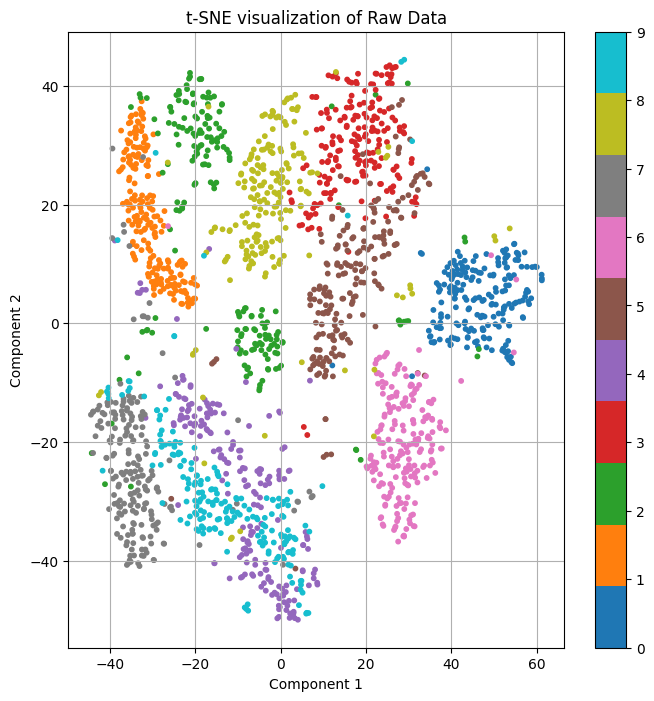

Running t-SNE...

--- METRICS ---
Silhouette Score: -0.0956
Davies-Bouldin Index: 19.9506
Calinski-Harabasz Index: 103.9479


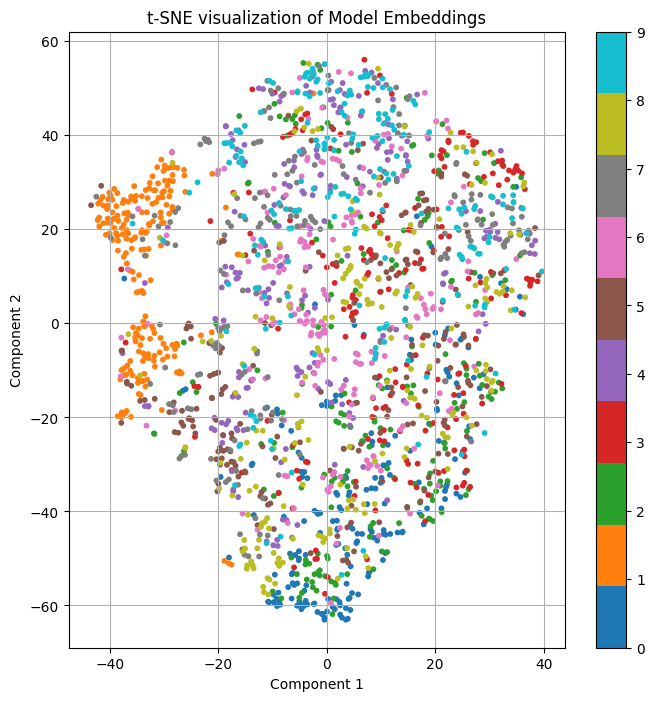

In [28]:
data_2d_raw, tsne_metric_raw = plot_tsne(test_samples[0], test_samples[1], title="t-SNE visualization of Raw Data")
data_2d_embeddings, tsne_metric_embeddings = plot_tsne(embeddings_samples[0], embeddings_samples[1], title="t-SNE visualization of Model Embeddings")